# Peanut Leaf Spot Defoliation and Yield Analysis (Workshop Demo)

This notebook is built for beginners and uses a **provided csv dataset** from `data/` so we can focus on analysis.

## Background

- In this workshop module, we will use real data to walk through an example on how to use Python to **estimate yield loss due to foliar disease**. The analysis will use data four decades of field studies where yield and defoliation percent was measured for early leaf spot on Spanish peanut cultivars.

- The data and analysis is modeled after **Estimation of Peanut Yield Losses Resulting From Early Leaf Spot on Spanish Cultivars in Oklahoma: A 26-Year Summary** by Maira R. Duffeck, John P. Damicone, Ken E. Jackson, Rebecca S. Bennet, Kelly D. Chamberlin and Todd A. Baughman (doi:10.1094/PDIS-09-24-1815-RE).

- At the end of this module, you should be familiar with:
  - Supplying context and prompting AI to help with data visualization
  - Using functions to create reusbale and reproducible code
  - Wrangling multi-year field trial data to estimate yield loss due to disease

## Understanding the Methods with AI Assistance

We all have diverse research backgrounds. Before we dive into the analysis, let's use AI to build a solid foundation in the statistical methods we'll be using. You'll work with two approaches: **OLS (Ordinary Least Squares) regression** and **mixed-effects modeling**.

**Step 1: Provide Context**
Start by telling AI about your research background. A good prompt should include:
- Your specific research focus (e.g., "I work on breeding for disease resistance" or "I am a plant disease epidemiologist")
- What you already know (e.g., "I'm familiar with linear regression but haven't used mixed models")
- The concept you want to understand (i.e., "OLS regression" or "random intercepts and slopes")

Example structure:

`I work on [your research area] in plant pathology. I want to understand [statistical concept] in the context of [your specific question]. I'm familiar with [what you know]. Can you explain [concept] using [your domain] examples?`

**Step 2: Request Visual or Intuitive Explanations**
Ask for comparisons or analogies:
- "Compare OLS vs. mixed models using a plant disease outbreak analogy"
- "Show me a simple example with 3 studies so I can see how random effects work"
- "What's the key difference between fixed effects and random effects in plain language?"

Continue the conversation until you feel familiar with both concepts we will be using today. You do not need to be an expert, but at least able to understand how the models we will use help us estimate yield loss due to disease using field trial data.

## 1. Set Up Environment and Dependencies

In this section we:
- Import Python libraries used for data tables, plotting, and modeling.
- Set a random seed so your results are repeatable.
- Print package versions to document the software environment.

If one of these imports fails, install that package and run the cell again.

In [1]:
# Core scientific Python stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Modeling libraries
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Display settings
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)

print("Versions:")
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"statsmodels: {sm.__version__}")

Versions:
numpy: 2.3.2
pandas: 2.3.1
statsmodels: 0.14.6


## 2. Load the Provided Dataset and Check Data Types

In this section we load the csv file that is already provided for the workshop:
- data/yield_loss_peanut.csv

We also run quick checks to confirm the data has the expected columns and shape.

In [2]:
from pathlib import Path

DATA_PATH = Path("data") / "yield_loss_peanut.csv"
REQUIRED_COLUMNS = ["study_id", "year", "defoliation_pct", "yield_kg_ha"]

DF = pd.read_csv(DATA_PATH)
DF.columns = DF.columns.str.strip()
DF = DF.rename(columns={
    "trial": "study_id",
    "defol_perc": "defoliation_pct",
    "yield": "yield_kg_ha",
})
missing_cols = [c for c in REQUIRED_COLUMNS if c not in DF.columns]
assert not missing_cols, f"Missing required columns: {missing_cols}"

print(f"Loaded: {DATA_PATH}")
print("Shape:", DF.shape)
print("Unique years:", DF["year"].nunique())
print("Unique studies:", DF["study_id"].nunique())
display(DF.head())

Loaded: data\yield_loss_peanut.csv
Shape: (586, 9)
Unique years: 28
Unique studies: 64


,study_id,year,variety_type,state,trial_loc,treat,treat_code,defoliation_pct,yield_kg_ha
0,1,1990,Runner,Oklahoma,Plat,1,BR,0.0,2196
1,1,1990,Runner,Oklahoma,Plat,2,BR,0.0,2559
2,1,1990,Runner,Oklahoma,Plat,3,UTC,24.8,2341
3,2,1991,Runner,Oklahoma,Plat,1,BR,10.0,3829
4,2,1991,Runner,Oklahoma,Plat,2,BR,18.7,3521


In [3]:
print("\nData Types:\n", DF.dtypes)


Data Types:
 study_id             int64
year                 int64
variety_type        object
state               object
trial_loc           object
treat                int64
treat_code          object
defoliation_pct    float64
yield_kg_ha          int64
dtype: object


## 2A. Filter data based on criteria for inclusion

To clean the data prior to analysis, the authors used the following criteria:
- Remove any studies where the variety was not Spanish
- Within-study differences in defoliation is less than 10%

In python, we use **masking** to filter data using Boolean conditions

In [4]:
print("Number of studies prior to filtering:", DF["study_id"].nunique())

# Initiate a new dataframe to store filtered data
DF_FILTERED = DF.copy()

# Criteria 1: Remove studies with cultivars other than 'Spanish'
mask_variety = DF["variety_type"] == "Spanish"
DF_FILTERED = DF_FILTERED[mask_variety]
print("Number of studies after filtering by variety:", DF_FILTERED["study_id"].nunique())

# Criteria 2: Remove studies where within-study defoliation range is less than 10%
DF_FILTERED["range"] = DF_FILTERED.groupby("study_id")["defoliation_pct"].transform(lambda x: x.max() - x.min())
mask_range = DF_FILTERED["range"] >= 10
DF_FILTERED = DF_FILTERED[mask_range]
print("Number of studies after filtering by defoliation range:", DF_FILTERED["study_id"].nunique())


# Summarize the remaining data to include study_id, number of observations, year, variety_type, defoliation range (as min to max), and yield range
DF_FILTERED_SUMMARY = DF_FILTERED.groupby("study_id").agg(
    n_obs=("study_id", "size"),
    year=("year", "first"),
    variety_type=("variety_type", "first"),
    defoliation_range=("defoliation_pct", lambda x: f"{x.min()} - {x.max()}"),
    yield_range=("yield_kg_ha", lambda x: f"{x.min()} - {x.max()}")
)

pd.set_option('display.max_rows', None)
display(DF_FILTERED_SUMMARY)


Number of studies prior to filtering: 64
Number of studies after filtering by variety: 49
Number of studies after filtering by defoliation range: 49


,n_obs,year,variety_type,defoliation_range,yield_range
study_id,,,,,
16,5,1990,Spanish,8.2 - 91.5,2396 - 3376
17,3,1991,Spanish,0.0 - 13.5,2922 - 3303
18,5,1991,Spanish,0.0 - 49.0,3067 - 3630
19,4,1991,Spanish,16.9 - 92.5,1845 - 2783
20,5,1991,Spanish,0.0 - 75.6,2668 - 4327
21,9,1991,Spanish,0.0 - 29.4,3684 - 4356
22,10,1992,Spanish,4.7 - 92.7,3258 - 4989
23,7,1992,Spanish,6.0 - 90.0,2011 - 3766
24,6,1993,Spanish,1.0 - 76.0,1540 - 2102


## 2B. Simple Data Visualization

These quick visuals help us understand the dataset before beginning any analyses.

We will plot:
- Average yield by study (bar chart)
- Average yearly trends for defoliation and yield (line charts)
- Yield spread by study (boxplot)

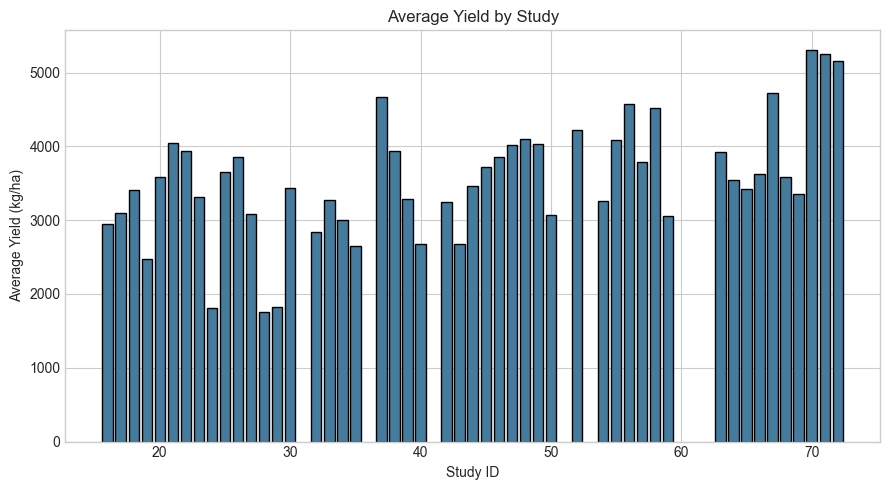

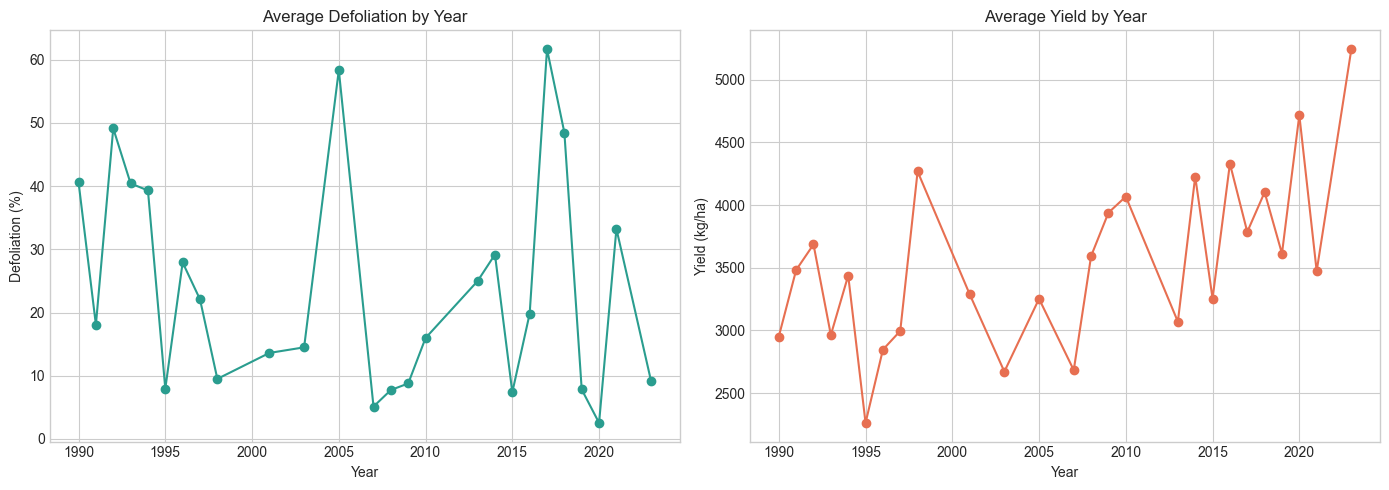

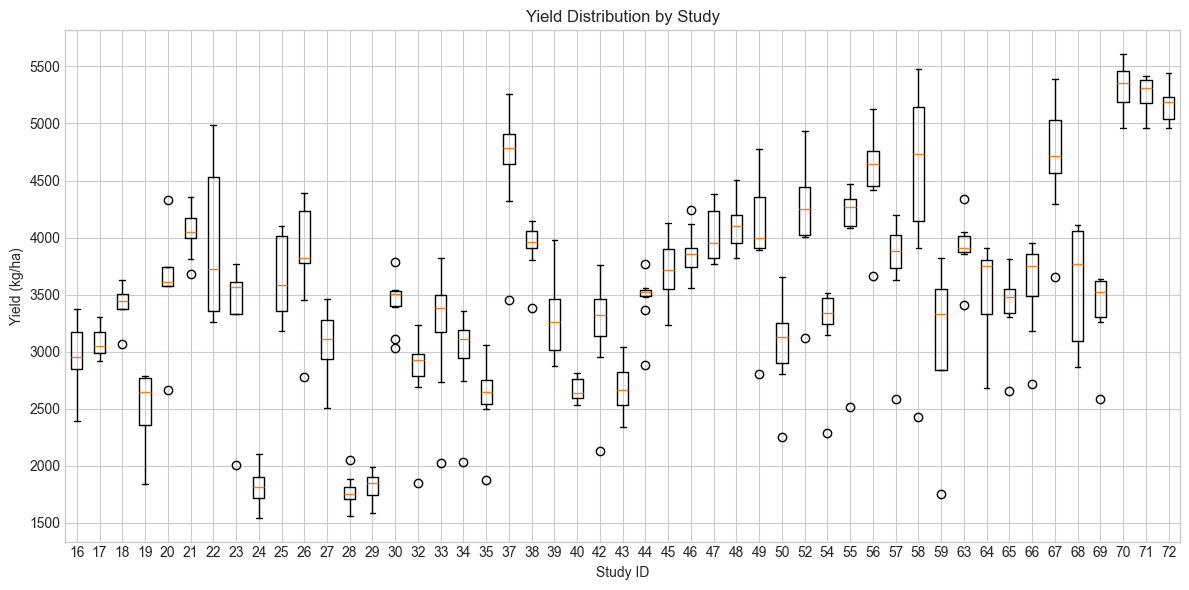

In [5]:
# 1) Average yield by study (simple bar chart)
study_mean = DF_FILTERED.groupby("study_id", as_index=False)["yield_kg_ha"].mean().sort_values("yield_kg_ha", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(study_mean["study_id"], study_mean["yield_kg_ha"], color="#457B9D", edgecolor="black")
plt.title("Average Yield by Study")
plt.xlabel("Study ID")
plt.ylabel("Average Yield (kg/ha)")
plt.tight_layout()
plt.show()

# 2) Yearly averages to show overall trend over time
yearly = DF_FILTERED.groupby("year", as_index=False).agg(
    mean_defoliation_pct=("defoliation_pct", "mean"),
    mean_yield_kg_ha=("yield_kg_ha", "mean"),
)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(yearly["year"], yearly["mean_defoliation_pct"], marker="o", color="#2A9D8F")
ax[0].set_title("Average Defoliation by Year")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Defoliation (%)")

ax[1].plot(yearly["year"], yearly["mean_yield_kg_ha"], marker="o", color="#E76F51")
ax[1].set_title("Average Yield by Year")
ax[1].set_xlabel("Year")
ax[1].set_ylabel("Yield (kg/ha)")

plt.tight_layout()
plt.show()

# 3) Boxplot: yield spread within each study
study_ids = sorted(DF_FILTERED["study_id"].unique())
box_data = [DF_FILTERED.loc[DF_FILTERED["study_id"] == sid, "yield_kg_ha"].values for sid in study_ids]

plt.figure(figsize=(12, 6))
plt.boxplot(box_data, tick_labels=study_ids)
plt.title("Yield Distribution by Study")
plt.xlabel("Study ID")
plt.ylabel("Yield (kg/ha)")
plt.tight_layout()
plt.show()

## 2C. Simple Data Visualization - Using AI

What else can we learn about the data before jumping into analyses? Leverage AI tools and your own creativity to dive further into the data.

Start by giving your AI tool context of the problem you're trying to address. Describe the dataset (column labels, data structure) and the objective of your analysis. Specificy the coding language (Python) and module (matplotlib) you want the AI to prepare code for. Use this template to help format your prompt:

`I have [data description]. I want to [objective]. Use [language/modules]. Output [format]. Explain [concept] in the context of [domain].`

Some prompt ideas:
- Visualize the distribution of your cateogorical data  (i.e., trial location, year, variety type)
- Describe the distribution of defoliation data (skewed, normal, bimodal)
- Help identify individual studies that may be outliers (extreme low or high yields).
 

After, **verify the AI-suggested code** to ensure the output is correct by using what you learned about matplotlib syntax from the previous section. If you don't understand something, **use AI to explain the code in plain language**

In [6]:
# Enter and execute your code in this cell

## 3A. Prepare Tools Needed for Analysis

In this section, we will define the functions that will help us complete the analysis

Python has many modules (e.g., matplotlib, numpy, pandas, statsmodels) that will cover **most** of your needs. But often, we can wrap them in our functions to work better for our data. Functions make our code more readable, modular and reuseable. 

This section defines the two core modeling functions used in this notebook:
- `fit_trial_ols`: fits one linear model per study (single-trial OLS)
- `fit_mixed_random_coeff`: fits a random-effects model with random intercept and slope by study
- `damage coefficient`: represents percent yield loss relative for each unit increase in defoliation
- `predicted_yield_from_fixed`: computes the predicted yield from fixed-effect coefficients

In [7]:
def fit_trial_ols(df: pd.DataFrame) -> pd.DataFrame:
    """Fit OLS per study and return intercept/slope table."""
    out = []
    for sid, g in df.groupby("study_id"):
        X = sm.add_constant(g["defoliation_pct"])
        y = g["yield_kg_ha"]
        m = sm.OLS(y, X).fit()
        out.append({
            "study_id": sid,
            "intercept": float(m.params["const"]),
            "slope": float(m.params["defoliation_pct"]),
            "r2": float(m.rsquared),
        })
    return pd.DataFrame(out).sort_values("study_id").reset_index(drop=True)


def fit_mixed_random_coeff(df: pd.DataFrame):
    """Fit random intercept and slope model by study using MixedLM."""
    model = smf.mixedlm(
        "yield_kg_ha ~ defoliation_pct",
        data=df,
        groups=df["study_id"],
        re_formula="~defoliation_pct",
    )
    result = model.fit(reml=False, method="powell", maxiter=1000)
    return result

def damage_coefficient(beta0: float, beta1: float) -> float:
    """Relative yield-loss percent per +1% defoliation."""
    return abs(beta1) / beta0 * 100

def predicted_yield_from_fixed(defol_levels: np.ndarray, beta0: float, beta1: float) -> pd.DataFrame:
    pred = beta0 + beta1 * defol_levels
    return pd.DataFrame({
        "defoliation_pct": defol_levels,
        "predicted_yield_kg_ha": pred,
    })


## 3B. Fit OLS Regression Models for Each Trial

In this section, we implement the **ordinary least squares (OLS) approach** as described in the manuscript.

**Methodology:**
- For each study/trial independently, fit: `yield = β₀ + β₁ × defoliation + ε`
- Estimate intercept (β₀) and slope (β₁) parameters for each trial
- Calculate the **interdecile (ID) range** (90th - 10th percentile) to summarize the distribution of coefficients across all trials
- The ID range describes the range of trial-level responses and heterogeneity among studies

**Interpretation:**
- β₀ (intercept): Expected yield when defoliation = 0
- β₁ (slope): Decline in expected yield per 1% increase in defoliation (kg/ha per %−¹)
- Negative β₁ indicates yield declines with increasing defoliation

OLS Coefficients Estimated Independently for Each Trial


,study_id,intercept,slope,r2
0,16,3229.848630,-6.859887,0.398903
1,17,3176.000000,-18.814815,0.571429
2,18,3489.000000,-8.612245,0.805049
3,19,3073.195782,-13.091017,0.950814
4,20,3884.303417,-16.204288,0.770707
5,21,4149.239518,-7.149369,0.198667
6,22,4879.289626,-17.130404,0.950334
7,23,4040.451724,-17.497091,0.755010
8,24,1853.120512,-1.543656,0.048739
9,25,4344.129574,-14.003440,0.905069



Distribution Summary of Trial-Level Coefficients

Intercept (β₀) Statistics (kg/ha):
  10th percentile: 2,788.49
  Mean: 3,846.66
  90th percentile: 4,960.14
  Interdecile Range (ID): 2,171.65

Slope (β₁) Statistics (kg/ha per % defoliation):
  10th percentile: -20.06
  Mean: -12.57
  90th percentile: -4.58
  Interdecile Range (ID): 15.48


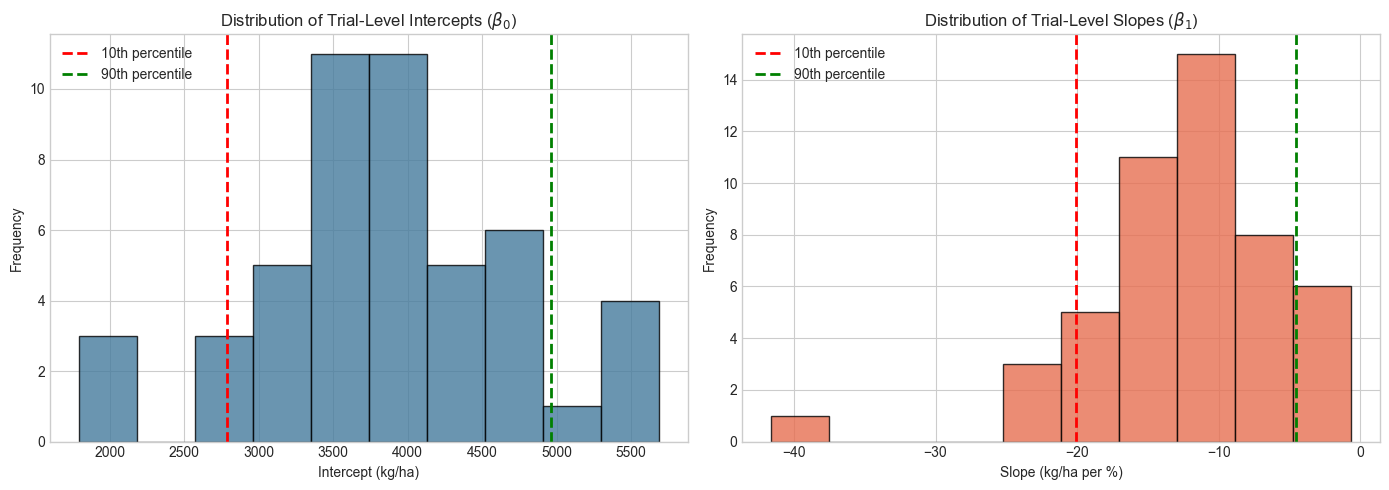

In [8]:
# Fit one OLS model per study (trial-level analysis)
ols_table = fit_trial_ols(DF_FILTERED)
print("=" * 70)
print("OLS Coefficients Estimated Independently for Each Trial")
print("=" * 70)
display(ols_table)

# Calculate interdecile range (ID) for intercepts and slopes
print("\n" + "=" * 70)
print("Distribution Summary of Trial-Level Coefficients")
print("=" * 70)
id_intercept = np.percentile(ols_table["intercept"], 90) - np.percentile(ols_table["intercept"], 10)
id_slope = np.percentile(ols_table["slope"], 90) - np.percentile(ols_table["slope"], 10)

print(f"\nIntercept (β₀) Statistics (kg/ha):")
print(f"  10th percentile: {np.percentile(ols_table['intercept'], 10):,.2f}")
print(f"  Mean: {ols_table['intercept'].mean():,.2f}")
print(f"  90th percentile: {np.percentile(ols_table['intercept'], 90):,.2f}")
print(f"  Interdecile Range (ID): {id_intercept:,.2f}")

print(f"\nSlope (β₁) Statistics (kg/ha per % defoliation):")
print(f"  10th percentile: {np.percentile(ols_table['slope'], 10):,.2f}")
print(f"  Mean: {ols_table['slope'].mean():,.2f}")
print(f"  90th percentile: {np.percentile(ols_table['slope'], 90):,.2f}")
print(f"  Interdecile Range (ID): {id_slope:,.2f}")

# Visualization: Distribution of trial-level intercepts and slopes
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(ols_table["intercept"], bins=10, color="#457B9D", edgecolor="black", alpha=0.8)
ax[0].axvline(np.percentile(ols_table["intercept"], 10), color="red", linestyle="--", linewidth=2, label="10th percentile")
ax[0].axvline(np.percentile(ols_table["intercept"], 90), color="green", linestyle="--", linewidth=2, label="90th percentile")
ax[0].set_title(r"Distribution of Trial-Level Intercepts ($\beta_0$)")
ax[0].set_xlabel("Intercept (kg/ha)")
ax[0].set_ylabel("Frequency")
ax[0].legend()

ax[1].hist(ols_table["slope"], bins=10, color="#E76F51", edgecolor="black", alpha=0.8)
ax[1].axvline(np.percentile(ols_table["slope"], 10), color="red", linestyle="--", linewidth=2, label="10th percentile")
ax[1].axvline(np.percentile(ols_table["slope"], 90), color="green", linestyle="--", linewidth=2, label="90th percentile")
ax[1].set_title(r"Distribution of Trial-Level Slopes ($\beta_1$)")
ax[1].set_xlabel("Slope (kg/ha per %)")
ax[1].set_ylabel("Frequency")
ax[1].legend()

plt.tight_layout()
plt.show()

## 3C. Fit Random Coefficient Model with Random Intercept and Slope

In this section, we implement the **random coefficient (mixed-effects) model** to account for the random effect of each study on both intercept and slope.

**Methodology:**
- Fit a linear mixed-effects model: `yield = (β₀ + u₀ᵢ) + (β₁ + u₁ᵢ) × defoliation + εᵢⱼ`
  - β₀, β₁: **population-average** (fixed-effects) intercept and slope
  - u₀ᵢ, u₁ᵢ: random effects for study *i* on intercept and slope
  - εᵢⱼ: residual error
- Estimate **Best Linear Unbiased Predictors (BLUPs)**: b̂β₀, b̂β₁ for each study-specific intercept and slope
- Use **maximum likelihood estimation** (via `lmer` function in statsmodels)

**Interpretation:**
- Population-average β₀ and β₁ represent the overall trend across all studies
- Study-specific BLUPs account for heterogeneity among studies
- The model partitions variance into between-study and within-study components

In [9]:
# Fit random intercept and slope model using MixedLM (equivalent to lmer in R)
mixed_res = fit_mixed_random_coeff(DF_FILTERED)

print("=" * 70)
print("Random Coefficient Model (Mixed-Effects Model) Summary")
print("=" * 70)
print(mixed_res.summary())

# Extract population-average (fixed-effects) parameters
beta0_hat = float(mixed_res.fe_params["Intercept"])
beta1_hat = float(mixed_res.fe_params["defoliation_pct"])

print("\n" + "=" * 70)
print("Population-Average Fixed-Effects Parameters")
print("=" * 70)
print(f"Population-average intercept (β₀): {beta0_hat:,.2f} kg/ha")
print(f"Population-average slope (β₁): {beta1_hat:,.2f} kg/ha per 1% defoliation")

# Compute damage coefficient from fixed effects
Dc = damage_coefficient(beta0_hat, beta1_hat)
print(f"\nDamage Coefficient (Dc): {Dc:.3f}% relative yield loss per +1% defoliation")
print(f"  Interpretation: For every 1% increase in defoliation, yield decreases by {Dc:.2f}% of the baseline yield.")

# Extract study-specific random effects (BLUPs)
print("\n" + "=" * 70)
print("Study-Specific Random Effects (BLUPs) - First 10 Studies")
print("=" * 70)
re_dict = mixed_res.random_effects
print("\nRandom intercepts (u₀ᵢ) and slopes (u₁ᵢ):")
for i, (study_id, effects) in enumerate(list(re_dict.items())[:10]):
    print(f"  Study {study_id}: Intercept effect = {effects.get('Group', 0):8.2f}, Slope effect = {effects.get('defoliation_pct', 0):8.2f}")

# Show predicted yield at example defoliation levels using population-average parameters
defol_levels = np.array([10, 20, 40, 60, 80])
pred_table = predicted_yield_from_fixed(defol_levels, beta0_hat, beta1_hat)
print("\n" + "=" * 70)
print("Predicted Yield from Population-Average Model")
print("=" * 70)
print(pred_table)

Random Coefficient Model (Mixed-Effects Model) Summary
                     Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        yield_kg_ha
No. Observations:         482            Method:                    ML         
No. Groups:               49             Scale:                     65525.9427 
Min. group size:          3              Log-Likelihood:            -3473.5711 
Max. group size:          19             Converged:                 Yes        
Mean group size:          9.8                                                  
-------------------------------------------------------------------------------
                              Coef.    Std.Err.    z    P>|z|  [0.025   0.975] 
-------------------------------------------------------------------------------
Intercept                     3836.986  126.842  30.250 0.000 3588.380 4085.592
defoliation_pct                -12.252    0.850 -14.410 0.000  -13.918  -10.585
Group 

## 4. Visualize Results

This section visualizes the two modeling methods used in this notebook and compares their trends:
- Single-trial OLS fits (one line per study)
- Random coefficient mixed-effects model (population-average trend and study-specific predictions)

Visualization: OLS and Random Coefficient Model


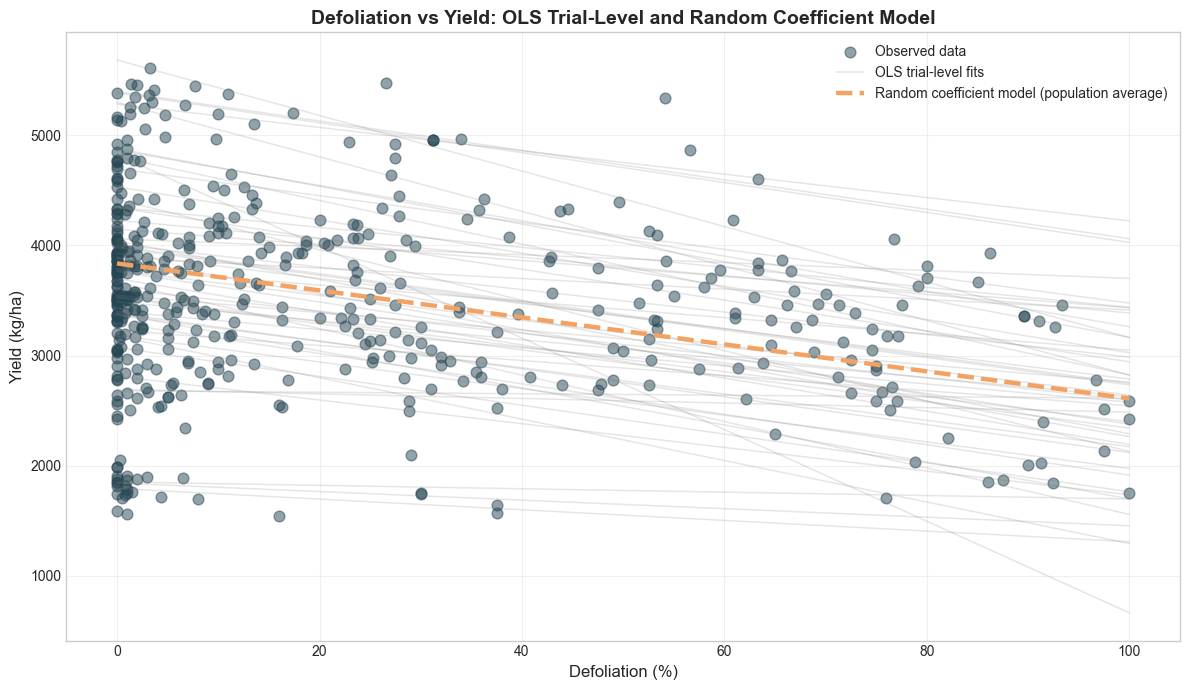

In [10]:
print("=" * 70)
print("Visualization: OLS and Random Coefficient Model")
print("=" * 70)

x_grid = np.linspace(DF_FILTERED["defoliation_pct"].min(), DF_FILTERED["defoliation_pct"].max(), 200)
y_mixed_grid = beta0_hat + beta1_hat * x_grid

# Visualization 1: Observed data, OLS trial lines, and mixed-model population trend
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    DF_FILTERED["defoliation_pct"],
    DF_FILTERED["yield_kg_ha"],
    alpha=0.5,
    color="#264653",
    s=60,
    label="Observed data",
)

# OLS trial-level lines
ols_labeled = False
for _, row in ols_table.iterrows():
    y_trial = row["intercept"] + row["slope"] * x_grid
    if not ols_labeled:
        ax.plot(x_grid, y_trial, color="gray", alpha=0.2, linewidth=1.1, label="OLS trial-level fits")
        ols_labeled = True
    else:
        ax.plot(x_grid, y_trial, color="gray", alpha=0.2, linewidth=1.1)

# Mixed-model population-average line
ax.plot(
    x_grid,
    y_mixed_grid,
    color="#F4A261",
    linewidth=3.2,
    linestyle="--",
    label="Random coefficient model (population average)",
)

ax.set_title("Defoliation vs Yield: OLS Trial-Level and Random Coefficient Model", fontsize=14, fontweight="bold")
ax.set_xlabel("Defoliation (%)", fontsize=12)
ax.set_ylabel("Yield (kg/ha)", fontsize=12)
ax.legend(fontsize=10, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()